In [10]:
# --- Import Modules --- #
import pandas as pd
from sklearn.model_selection import StratifiedKFold

from sklearn.utils.multiclass import unique_labels
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef

from sklearn.metrics import confusion_matrix

import sys
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.animation as animation

import statistics 

import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from GRMMFN import ReflexFuzzyNeuroNetwork
import time
import string
import random

data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels.csv')

print(data.head(8000))
data = data.iloc[:,1:]
print(data)


         Time  Displacement  Force     Work  Label
0      0.0000             4   0.00     0.00      1
1      0.0500             3   0.00     0.00      1
2      0.1000             0   0.00     0.00      1
3      0.1500             3   0.00     0.00      1
4      0.2000             2   0.00     0.00      1
...       ...           ...    ...      ...    ...
7995  39.7497           413  22.02  9093.67      7
7996  39.7997           414  22.06  9132.89      7
7997  39.8497           415  22.06  9154.95      7
7998  39.8997           412  22.06  9088.77      7
7999  39.9497           407  22.06  8978.47      7

[8000 rows x 5 columns]
       Displacement  Force    Work  Label
0                 4   0.00    0.00      1
1                 3   0.00    0.00      1
2                 0   0.00    0.00      1
3                 3   0.00    0.00      1
4                 2   0.00    0.00      1
...             ...    ...     ...    ...
10795            10  21.40  213.95      9
10796             9  21.44 

In [11]:
# initialise a StratifiedKFold object with 5 folds and
# declare the column that we which to group by which in this
# case is the column called "label"
skf = StratifiedKFold(n_splits=10, shuffle= True, random_state=42)

target = data.loc[:,'Label']


In [12]:
# for each fold split the data into train and validation 
# sets and save the fold splits to csv
fold_no = 1
for train_index, val_index in skf.split(data, target):
    train = data.loc[train_index,:]
    val = data.loc[val_index,:]
    train.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\cross_val_data\\' + 'train_fold_' + str(fold_no) + '.csv')
    val.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\cross_val_data\\' + 'val_fold_' + str(fold_no) + '.csv')
    fold_no += 1

[1 1 1 ... 1 1 1]
Accuracy: 11.11111111111111%
[1 1 1 ... 1 1 1]
Accuracy:  [0.1111111111111111]
done with count:  [1]
[1 1 1 ... 9 9 9]
Accuracy: 87.87037037037037%
[1 1 1 ... 9 9 9]
Accuracy:  [0.1111111111111111, 0.8787037037037037]
done with count:  [1, 2]
[1 1 1 ... 9 9 9]
Accuracy: 82.68518518518519%
[1 1 1 ... 9 9 9]
Accuracy:  [0.1111111111111111, 0.8787037037037037, 0.8268518518518518]
done with count:  [1, 2, 3]
[1 1 1 ... 1 1 1]
Accuracy: 11.11111111111111%
[1 1 1 ... 1 1 1]
Accuracy:  [0.1111111111111111, 0.8787037037037037, 0.8268518518518518, 0.1111111111111111]
done with count:  [1, 2, 3, 4]
[1 1 1 ... 1 1 1]
Accuracy: 11.11111111111111%
[1 1 1 ... 1 1 1]
Accuracy:  [0.1111111111111111, 0.8787037037037037, 0.8268518518518518, 0.1111111111111111, 0.1111111111111111]
done with count:  [1, 2, 3, 4, 5]
[1 1 1 ... 9 9 9]
Accuracy: 84.44444444444444%
[1 1 1 ... 9 9 9]
Accuracy:  [0.1111111111111111, 0.8787037037037037, 0.8268518518518518, 0.1111111111111111, 0.1111111111111111

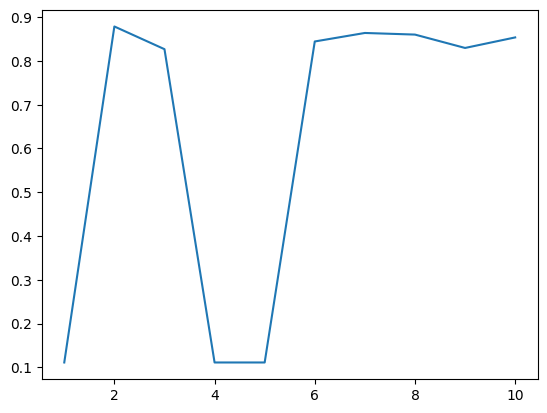

In [13]:
count = 1
accuracy = []
count_array = []
for fold_no in range(1,11):
# fold_no = 1
    from GRMMFN import ReflexFuzzyNeuroNetwork
#     newdata = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\cross_val_data\\' + 'train_fold_' + str(fold_no) + '.csv')
    newtrain = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\cross_val_data\\' + 'train_fold_' + str(fold_no) + '.csv')
    newval = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\cross_val_data\\' + 'val_fold_' + str(fold_no) + '.csv')

    newtrain = newtrain.iloc[:,1:]
    newval = newval.iloc[:,1:]
    # print(newtrain)

    X_train = newtrain.iloc[:,:-1] # for every y (class) we get a 4-D array. E.g., I'm in the 5th dimension. 
    y_train = newtrain.iloc[:,-1] # same as saying y coresponds to the respective classes. E.g., w = 1,2 or 3.
    # print(X_train)
    # print(y_train)


    X_test = newval.iloc[:,:-1] # for every y (class) we get a 4-D array. E.g., I'm in the 5th dimension. 
    y_test = newval.iloc[:,-1] # same as saying y coresponds to the respective classes. E.g., w = 1,2 or 3.
    # print(X_test)
    # print(y_test)

    scaler_min_max = MinMaxScaler(feature_range=(0.01, .99))
    X_train = scaler_min_max.fit_transform(X_train)
    X_test = scaler_min_max.fit_transform(X_test)
    # print(X_train.shape)
    # print(X_train)
    # print(X_test.shape)
    # print(X_test)
    # print(y_train)


    y_train, y_test = y_train.values, y_test.values # Transpose the y_train and y_test data. 
                                # Essentailly we go from a 66X1 matrices to a 1x66 matrices. 
    X_train, X_test = X_train.T, X_test.T 
    # print(y_train)



    nn = ReflexFuzzyNeuroNetwork(gamma=2, theta=.001)
# '''
# X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
# y_train after the y_train.values (transpose) is an array[column 5]
# '''
# --- Train network --- #
    # train = nn.train(X_train, y_train)
    # test = nn.test(X_test,y_test)


    nn.train(X_train, y_train)

    y_predlr = nn.test(X_test,y_test)
    print(y_predlr)



    def plot(y_true, y_pred):
        labels = unique_labels(y_test)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

        return table
    

    def plot2(y_true, y_pred):
        labels = unique_labels(y_test)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

        return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')

    # plot2(y_test, y_predlr)
    accuracy_score1 = accuracy_score(y_test, y_predlr)
    accuracy.append(accuracy_score1)
    count_array.append(count)

    print("Accuracy: ", accuracy)
    print("done with count: ", count_array)

    

    count +=1

    # gamma_range = range(1,5)
    # nn_scores = []
    # for g in gamma_range:
    #     nn = ReflexFuzzyNeuroNetwork(gamma=g, theta=.03)
    # # '''
    # # X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
    # # y_train after the y_train.values (transpose) is an array[column 5]
    # # '''
    # # --- Train network --- #
    #     train = nn.train(X_train, y_train)
    #     test = nn.test(X_test,y_test)
    #     nn_scores.append(test)
    # print(nn_scores)


print("Accuracy out of loop: ", accuracy)
print("Count out of loop: ", count_array)

# plt.plot(count_array, accuracy)
# plt.show()



Accuracy out of loop:  [0.1111111111111111, 0.8787037037037037, 0.8268518518518518, 0.1111111111111111, 0.1111111111111111, 0.8444444444444444, 0.8638888888888889, 0.8601851851851852, 0.8296296296296296, 0.8537037037037037]
Count out of loop:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
std 0.35775591230716663
mean 0.6290740740740741


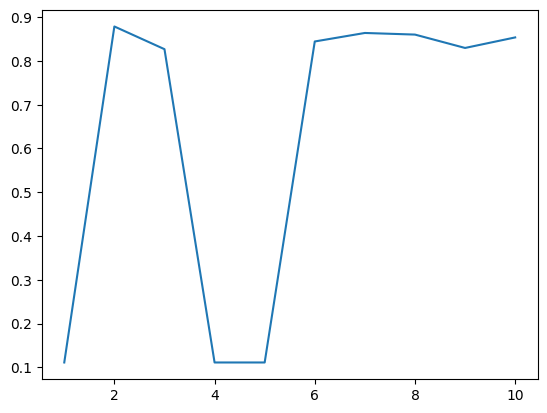

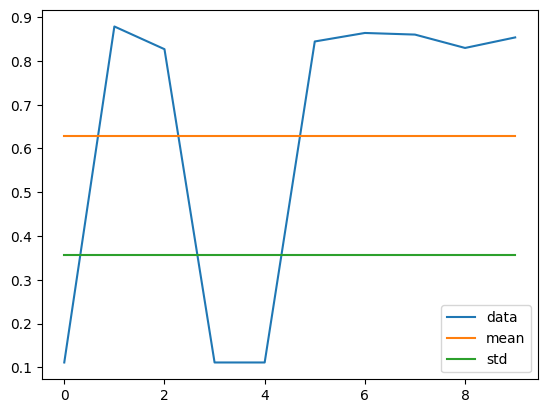

In [14]:
print("Accuracy out of loop: ", accuracy)
print("Count out of loop: ", count_array)

print("std", statistics.stdev(accuracy))
print("mean", statistics.mean(accuracy))


# plt.plot(count_array, accuracy)
# plt.show()

df = pd.DataFrame({
      'data': accuracy,
      'mean': [statistics.mean(accuracy) for i in range(1, len(accuracy)+1, 1)],
      'std': [statistics.stdev(accuracy) for i in range(1, len(accuracy)+1, 1)]})

df.plot()
plt.show()